# Week Problem Set: Data Wrangling

## Context
Patient data is divided across three systems:
- Administrative
- Lab Results
- Lifestyle Surveys

For this assignment, will work with these datasets **independently** and focus only on **data wrangling tasks**.

---

## Datasets
1. patient_demographics.csv  
   - Patient ID, Age, Sex, Geography
     

2. clinical_data.csv  
   - Patient ID, Cholesterol, Blood Pressure ("120/80"), BMI
  

3. lifestyle_factors.csv  
   - Patient ID, Smoking, Diet, Heart Attack Risk (Target)

---

## Objectives
- Inspecting structure and quality
- Handling missing values
- Fixing data formats
- Identifying and treating anomalies

---

## Important Note
This is a guided notebook. I am supposed to
- Think critically
- Make decisions (and justify them)
- Explore different approaches

---

In [5]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Load datasets
demographics = pd.read_csv("/home/nilima/AIF/wk1_data_wrangling_problem/data/patient_demographics.csv")
clinical = pd.read_csv("/home/nilima/AIF/wk1_data_wrangling_problem/data/clinical_data.csv")
lifestyle = pd.read_csv("/home/nilima/AIF/wk1_data_wrangling_problem/data/lifestyle_factors.csv")

# Basic Inspection

## Tasks:
- View first few rows
- Check datatypes
- Look at summary statistics

## Questions:
- Are there obvious data issues?
- Are datatypes appropriate?

## Hint:
- Use `.head()`, `.info()`, `.describe()` for all three dataframes to get a full picture of the data quality.
- Pandas documentation for reference: https://pandas.pydata.org/docs/user_guide/10min.html

In [8]:
print(demographics.head())

  Patient ID  Age     Sex  Income    Country      Continent  \
0    BMW7812   67    Male  261404  Argentina  South America   
1    CZE1114   21    Male  285768     Canada  North America   
2    BNI9906   21  Female  235282     France         Europe   
3    JLN3497   84    Male  125640     Canada  North America   
4    GFO8847   66    Male  160555   Thailand           Asia   

            Hemisphere  
0  Southern Hemisphere  
1  Northern Hemisphere  
2  Northern Hemisphere  
3  Northern Hemisphere  
4  Northern Hemisphere  


In [9]:
print(clinical.head())

  Patient ID  Cholesterol Blood Pressure  Heart Rate  Diabetes  \
0    BMW7812          208         158/88          72         0   
1    CZE1114          389         165/93          98         1   
2    BNI9906          324         174/99          72         1   
3    JLN3497          383        163/100          73         1   
4    GFO8847          318          91/88          93         1   

   Family History  Triglycerides        BMI  
0               0            286  31.251233  
1               1            235  27.194973  
2               0            587  28.176571  
3               1            378  36.464704  
4               1            231  21.809144  


In [10]:
print(lifestyle.head())

  Patient ID  Smoking  Obesity  Alcohol Consumption  Exercise Hours Per Week  \
0    BMW7812        1        0                    0                 4.168189   
1    CZE1114        1        1                    1                 1.813242   
2    BNI9906        0        0                    0                 2.078353   
3    JLN3497        1        0                    1                 9.828130   
4    GFO8847        1        1                    0                 5.804299   

        Diet  Stress Level  Heart Attack Risk  
0    Average             9                  0  
1  Unhealthy             1                  0  
2    Healthy             9                  0  
3    Average             9                  0  
4  Unhealthy             6                  0  


In [11]:
demographics.info()

<class 'pandas.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Patient ID  8763 non-null   str  
 1   Age         8763 non-null   int64
 2   Sex         8763 non-null   str  
 3   Income      8763 non-null   int64
 4   Country     8763 non-null   str  
 5   Continent   8763 non-null   str  
 6   Hemisphere  8763 non-null   str  
dtypes: int64(2), str(5)
memory usage: 479.4 KB


In [13]:
clinical.info()

<class 'pandas.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Patient ID      8763 non-null   str    
 1   Cholesterol     8763 non-null   int64  
 2   Blood Pressure  8763 non-null   str    
 3   Heart Rate      8763 non-null   int64  
 4   Diabetes        8763 non-null   int64  
 5   Family History  8763 non-null   int64  
 6   Triglycerides   8763 non-null   int64  
 7   BMI             8763 non-null   float64
dtypes: float64(1), int64(5), str(2)
memory usage: 547.8 KB


In [12]:
lifestyle.info()

<class 'pandas.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient ID               8763 non-null   str    
 1   Smoking                  8763 non-null   int64  
 2   Obesity                  8763 non-null   int64  
 3   Alcohol Consumption      8763 non-null   int64  
 4   Exercise Hours Per Week  8763 non-null   float64
 5   Diet                     8763 non-null   str    
 6   Stress Level             8763 non-null   int64  
 7   Heart Attack Risk        8763 non-null   int64  
dtypes: float64(1), int64(5), str(2)
memory usage: 547.8 KB


In [14]:
clinical.describe(include='all')

,Patient ID,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Triglycerides,BMI
count,8763,8763.000000,8763,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
unique,8763,NaN,3915,NaN,NaN,NaN,NaN,NaN
top,BMW7812,NaN,146/94,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,8,NaN,NaN,NaN,NaN,NaN
mean,NaN,259.877211,NaN,75.021682,0.652288,0.492982,417.677051,28.891446
std,NaN,80.863276,NaN,20.550948,0.476271,0.499979,223.748137,6.319181
min,NaN,120.000000,NaN,40.000000,0.000000,0.000000,30.000000,18.002337
25%,NaN,192.000000,NaN,57.000000,0.000000,0.000000,225.500000,23.422985
50%,NaN,259.000000,NaN,75.000000,1.000000,0.000000,417.000000,28.768999
75%,NaN,330.000000,NaN,93.000000,1.000000,1.000000,612.000000,34.324594


In [16]:
demographics.describe(include='all')

,Patient ID,Age,Sex,Income,Country,Continent,Hemisphere
count,8763,8763.000000,8763,8763.000000,8763,8763,8763
unique,8763,NaN,2,NaN,20,6,2
top,BMW7812,NaN,Male,NaN,Germany,Asia,Northern Hemisphere
freq,1,NaN,6111,NaN,477,2543,5660
mean,NaN,53.707977,NaN,158263.181901,NaN,NaN,NaN
std,NaN,21.249509,NaN,80575.190806,NaN,NaN,NaN
min,NaN,18.000000,NaN,20062.000000,NaN,NaN,NaN
25%,NaN,35.000000,NaN,88310.000000,NaN,NaN,NaN
50%,NaN,54.000000,NaN,157866.000000,NaN,NaN,NaN
75%,NaN,72.000000,NaN,227749.000000,NaN,NaN,NaN


In [17]:
lifestyle.describe(include='all')

,Patient ID,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Stress Level,Heart Attack Risk
count,8763,8763.000000,8763.000000,8763.000000,8763.000000,8763,8763.000000,8763.000000
unique,8763,NaN,NaN,NaN,NaN,3,NaN,NaN
top,BMW7812,NaN,NaN,NaN,NaN,Healthy,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,2960,NaN,NaN
mean,NaN,0.896839,0.501426,0.598083,10.014284,NaN,5.469702,0.358211
std,NaN,0.304186,0.500026,0.490313,5.783745,NaN,2.859622,0.479502
min,NaN,0.000000,0.000000,0.000000,0.002442,NaN,1.000000,0.000000
25%,NaN,1.000000,0.000000,0.000000,4.981579,NaN,3.000000,0.000000
50%,NaN,1.000000,1.000000,1.000000,10.069559,NaN,5.000000,0.000000
75%,NaN,1.000000,1.000000,1.000000,15.050018,NaN,8.000000,1.000000


In [18]:
demographics.isnull().sum()

Patient ID    0
Age           0
Sex           0
Income        0
Country       0
Continent     0
Hemisphere    0
dtype: int64

## Answers to Questions:
- Are there obvious data issues?<br>
Answer:<br>
Yes, after inspecting demographics, lifestyle and clinical datas. Here are few data issues that can be seen.<br>
    * Missing values are present 
    * Values that are supposed to be of dtype numeric is string. For eg: Blood Pressure is stored like "120/80"
    * There could be outliers,duplicates and inconsistent entries as well.

- Are datatypes appropriate?<br>
Answer: <br>
    * Columns like 'Age','BMI','Cholesterol' appear to be numeric. So they are appropriate.
    * But 'Blood Pressure' column should be split into Systolic and Diastolic in integer but is stored as strings/object.
    * Smoking, Heart attack, Risk are numeric but is categorial. We can treat them as categorial datas.
    * Most of the columns of numeric data types are appropriate but Blood Pressure and other categorial encodings need some data type fixes and maybe normalization.


# Data Cleaning

## 1. Blood Pressure Column

### Task:
- Inspect the Blood Pressure column

### Questions:
- Is it stored as a number or string?<br>
Answer: It is stored as string.
- Can we compute averages directly?<br>
Answer: No, we cannot compute mathematical operations on dtype 'string'


### Hint:
- Format looks like "120/80"
- Consider splitting into two columns
- https://pandas.pydata.org/docs/reference/api/pandas.Series.str.split.html

### Consequences:
- Keeping as string -> limits analysis
- Splitting -> enables calculations but increases feature count

In [19]:
clinical['Blood Pressure'].head(10)

0     158/88
1     165/93
2     174/99
3    163/100
4      91/88
5     172/86
6     102/73
7     131/68
8    144/105
9     160/70
Name: Blood Pressure, dtype: str

In [20]:
clinical['Blood Pressure'].dtype

<StringDtype(storage='python', na_value=nan)>

In [21]:
# clinical['Blood Pressure'].mean()

#Results in TypeError: Cannot perform reduction 'mean' with string dtype

In [22]:
# Splitting the Blood Pressure column into Systolic and Diastolic columns
clinical[['Systolic', 'Diastolic']] = clinical['Blood Pressure'].str.split('/', expand=True).astype(int)
print(clinical)

     Patient ID  Cholesterol Blood Pressure  Heart Rate  Diabetes  \
0       BMW7812          208         158/88          72         0   
1       CZE1114          389         165/93          98         1   
2       BNI9906          324         174/99          72         1   
3       JLN3497          383        163/100          73         1   
4       GFO8847          318          91/88          93         1   
...         ...          ...            ...         ...       ...   
8758    MSV9918          121          94/76          61         1   
8759    QSV6764          120        157/102          73         1   
8760    XKA5925          250         161/75         105         0   
8761    EPE6801          178         119/67          60         1   
8762    ZWN9666          356         138/67          75         1   

      Family History  Triglycerides        BMI  Systolic  Diastolic  
0                  0            286  31.251233       158         88  
1                  1           

In [23]:
clinical['Systolic'].mean()

np.float64(135.07565902088325)

In [25]:
clinical['Diastolic'].mean()

np.float64(85.1561109209175)

## Answers to Questions:
- Is it stored as a number or string?<br>
Answer:<br>
It is stored as string (object) and values looks like "120/80"<br>
    * <StringDtype(storage='python', na_value=nan)>

- Can we compute averages directly?<br>
Answer: <br> No, we cannot compute averges directly as we get a TypeError because the column is string.

    * Results in TypeError: Cannot perform reduction 'mean' with string dtype

## 2. Missing Values

### Task:
Identify columns with null values

### Questions:
- Which columns have missing values?
- Why might values be missing?

### Hint:
- Lifestyle → user did not answer (non-critical)
- Clinical → test not performed (critical)
- https://wesmckinney.com/book/data-cleaning

### Why Missing Data Matters
Missing data is not just an inconvenience, it can affect the **validity of your analysis**.

There are different types of missingness:
- **MCAR (Missing Completely at Random)** → no pattern (least problematic)
- **MAR (Missing at Random)** → depends on other variables
- **MNAR (Missing Not at Random)** → depends on the missing value itself (most problematic)

Understanding *why* data is missing helps decide how to handle it.

### Consequences of Different Choices

#### 1. Dropping Missing Values (`dropna`)
- Pros: simple, clean dataset  
- Cons: loses data, may introduce bias  

---

#### 2. Filling Missing Values (`fillna`)
- Pros: keeps dataset size, usable for modeling  
- Cons: adds assumptions, can distort data  

---

#### 3. Column-Specific Strategy
- Clinical → careful imputation or flag missing  
- Lifestyle → consider "Unknown" category  

### Key Takeaway:
There is **no single correct method**.  
The best approach depends on:
- Why data is missing  
- How much is missing  
- The impact on downstream analysis  


In [26]:
clinical.isna().sum()

Patient ID        0
Cholesterol       0
Blood Pressure    0
Heart Rate        0
Diabetes          0
Family History    0
Triglycerides     0
BMI               0
Systolic          0
Diastolic         0
dtype: int64

In [27]:
lifestyle.isna().sum()

Patient ID                 0
Smoking                    0
Obesity                    0
Alcohol Consumption        0
Exercise Hours Per Week    0
Diet                       0
Stress Level               0
Heart Attack Risk          0
dtype: int64

In [28]:
demographics.isna().sum()

Patient ID    0
Age           0
Sex           0
Income        0
Country       0
Continent     0
Hemisphere    0
dtype: int64

In [29]:
clinical.head(20)

,Patient ID,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Triglycerides,BMI,Systolic,Diastolic
0,BMW7812,208,158/88,72,0,0,286,31.251233,158,88
1,CZE1114,389,165/93,98,1,1,235,27.194973,165,93
2,BNI9906,324,174/99,72,1,0,587,28.176571,174,99
3,JLN3497,383,163/100,73,1,1,378,36.464704,163,100
4,GFO8847,318,91/88,93,1,1,231,21.809144,91,88
5,ZOO7941,297,172/86,48,1,1,795,20.146840,172,86
6,WYV0966,358,102/73,84,0,0,284,28.885811,102,73
7,XXM0972,220,131/68,107,0,0,370,22.221862,131,68
8,XCQ5937,145,144/105,68,1,0,790,35.809901,144,105
9,FTJ5456,248,160/70,55,0,1,232,22.558917,160,70


In [30]:
lifestyle.head(20)

,Patient ID,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Stress Level,Heart Attack Risk
0,BMW7812,1,0,0,4.168189,Average,9,0
1,CZE1114,1,1,1,1.813242,Unhealthy,1,0
2,BNI9906,0,0,0,2.078353,Healthy,9,0
3,JLN3497,1,0,1,9.828130,Average,9,0
4,GFO8847,1,1,0,5.804299,Unhealthy,6,0
5,ZOO7941,1,0,1,0.625008,Unhealthy,2,1
6,WYV0966,1,0,1,4.098177,Healthy,7,1
7,XXM0972,1,1,1,3.427929,Average,4,1
8,XCQ5937,1,1,0,16.868302,Average,5,0
9,FTJ5456,1,1,1,0.194515,Unhealthy,4,0


### Questions:
- Which columns have missing values? <br>
Answer: After checking for the null values in each tables using Pandas Library, it showed no nulls for all columns. <br><br><br>
- Why might values be missing?<br>
Answer: Values might be missing due to many reasons. Potential reasons could be:<br>
    * User may miss out or left blank during surveys.
    * Test may not be performed or simply not recorded. (Data may not exist)
    * Merge/Key mismatches across entire system so rows may have dropped.
    * Device/Sensor failures may have occured or data corruption 


# Exploratory Data Analysis (EDA)

## Univariate Analysis: Age Distribution

Univariate analysis examines **one variable at a time**.
The goal is to understand each column's distribution, central tendency, and spread before comparing variables.

We split variables into two types:
- **Numerical** (continuous): Age, Cholesterol, BMI, Blood Pressure
- **Categorical** (discrete): Sex, Smoking, Diet, Country

---

## 1. Numerical Variables : Distributions

### Task:
Plot histograms and KDE (Kernel Density Estimate) curves for: Age, Cholesterol, BMI

### Questions:
- Which variables are normally distributed?
- Which variables are skewed left or right?
- Are there any unexpected spikes or gaps?
- Based on the distribution shape, would any feature likely need a transformation before modeling?

### Hint:
- `sns.histplot(data=df, x='Age', kde=True)` draws a histogram with a density curve
- `plt.axvline(df['Age'].mean(), color='red', linestyle='--', label='Mean')` adds a mean line
- Skewness > 1 or < -1 is considered highly skewed

## Why This Matters

Many statistical models, such as **Linear Regression, Logistic Regression, and Linear Discriminant Analysis** assume that numerical features are approximately **normally distributed**. When this assumption is violated, it can lead to:

- Biased coefficients  
- Unreliable p-values  
- Poor model performance  

Even though tree-based models (like Decision Trees) do not require normality, highly skewed features can still negatively affect **distance-based algorithms** such as **KNN** or **SVM**.

This is why understanding the shape of your distributions early in **Exploratory Data Analysis (EDA)** is important. It helps determine whether transformations are needed before modeling.

---

## Common Transformations and When to Use Them

### 1. Log Transform — `np.log1p(x)`
Used when data is **right-skewed** (long tail on the right), such as income or cholesterol levels in some populations.

- Compresses large values  
- Pulls distribution closer to normal  
- Uses `log1p` (log(1 + x)) to safely handle zero values  

---

### 2. Square Root Transform — `np.sqrt(x)`
A milder transformation compared to log.

- Useful for **moderately right-skewed data**  
- Common for count data (e.g., number of medications)  
- Preserves more of the original structure  

---

### 3. Box-Cox Transform — `scipy.stats.boxcox(x)`
A powerful, data-driven transformation.

- Finds optimal power (λ) to best approximate normality  
- Requires all values to be **strictly positive**  
- Special cases:
  - λ = 0 → log transform  
  - λ = 0.5 → square root transform  

---

### 4. Yeo-Johnson Transform — `sklearn.preprocessing.PowerTransformer(method='yeo-johnson')`
A flexible alternative to Box-Cox.

- Works with **zero and negative values**  
- More suitable for real-world medical datasets  
- Automatically learns best transformation  

---

### 5. Standardization (Z-score) — `sklearn.preprocessing.StandardScaler`
Transforms features to have:

- Mean = 0  
- Standard deviation = 1  

Notes:

- Does **not change distribution shape**  
- Useful when features are on different scales (e.g., Age vs Cholesterol)  
- Does not fix skewness  

---

### 6. Min-Max Normalization — `sklearn.preprocessing.MinMaxScaler`
Rescales features to a fixed range:

- Values are scaled to **[0, 1]**  
- Does not fix skewness  

---

### Reference links:
- https://towardsdatascience.com/top-3-methods-for-handling-skewed-data-1334e0debf45/
- https://www.geeksforgeeks.org/python/data-normalization-with-pandas/


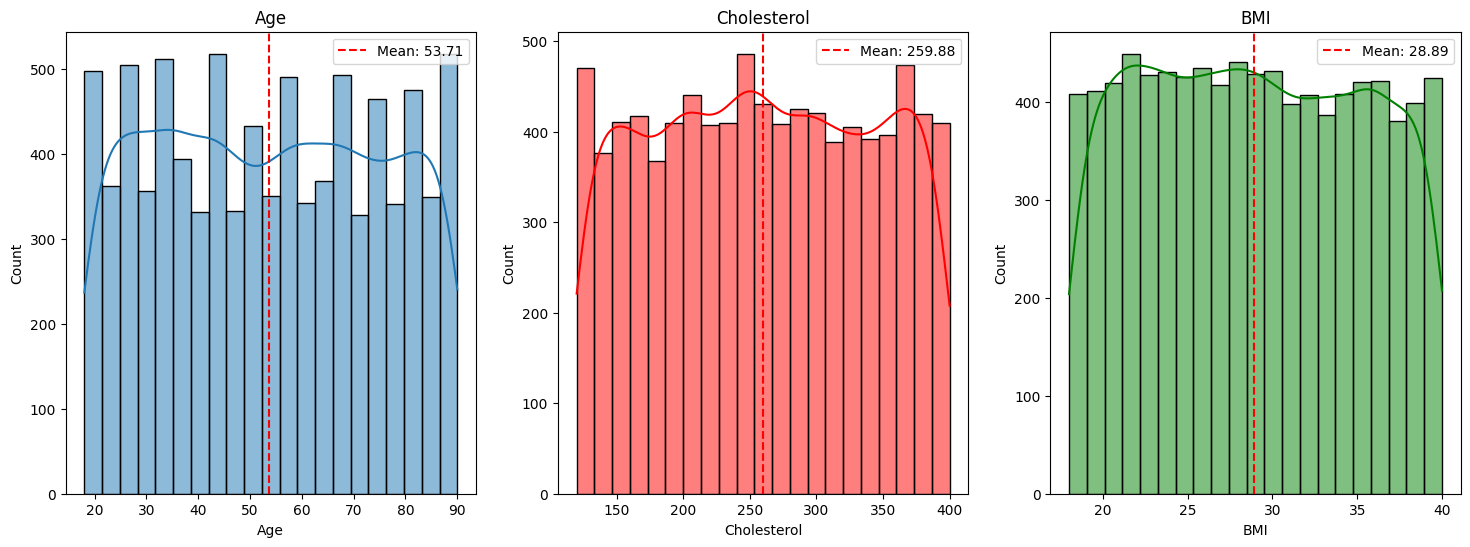

In [33]:
# My code here
fig, ax=plt.subplots(1,3,figsize=(18,6))

#for age
ax[0].set_title("Age")
sns.histplot(demographics,x='Age',kde=True,ax=ax[0])
ax[0].axvline(demographics['Age'].mean(), color='red', linestyle='--', label= f'Mean: {demographics['Age'].mean():.2f}')
ax[0].legend()

#for Cholesterol 
ax[1].set_title("Cholesterol")
sns.histplot(clinical,x="Cholesterol",kde=True,ax=ax[1],color='red')
ax[1].axvline(clinical['Cholesterol'].mean(),color='red',linestyle='--',label=f'Mean: {clinical['Cholesterol'].mean():.2f}')
ax[1].legend()

#for BMI
ax[2].set_title('BMI')
sns.histplot(clinical,kde=True,ax=ax[2],x='BMI',color='green')
ax[2].axvline(clinical['BMI'].mean(),color='red',linestyle='--',label=f"Mean: {clinical['BMI'].mean():.2f}")
ax[2].legend()

plt.show()



In [34]:
# My code here

# Checking for the Skewness 
cols=['Age','Cholesterol','BMI']
for col in cols:
    if col=='Age': df=demographics
    else: df= clinical
    skew_val=df[col].skew()
    print(f'For [{col}]=',skew_val)
    if skew_val <= 0.5 and skew_val >= -0.5:
        print('Approximately symmetrical')
    elif skew_val > 0.5 and skew_val <= 1:
        print('Moderately right skewed')
    elif skew_val > 1:
        print('Highly right skewed')
    elif skew_val < -1:
        print('Highly left skewed')
    elif skew_val >= -1 and skew_val < -0.5:
        print('moderately left skewed') 
    print('\n')



For [Age]= 0.028497567159389184
Approximately symmetrical


For [Cholesterol]= -0.0009547396917188217
Approximately symmetrical


For [BMI]= 0.035996421727899
Approximately symmetrical




### Questions:
- Which variables are normally distributed?<br>
Answer: Among Age, Cholesterol and BMI, none are perfectly normally distributed. They are approximately symmetrical as their values lies between [-0.5,0.5]<br><br>
- Which variables are skewed left or right?<br>
Answer:Among Age, Cholesterol and BMI, none are skewed left or right since they donot satisfy this condition.
    * if skew_val <= 0.5 and skew_val >= -0.5 then 'Approximately symmetrical'
    * if skew_val > 0.5 and skew_val <= 1 then 'Moderately right skewed'
    * if skew_val > 1 then 'Highly right skewed'
    * if skew_val < -1 then 'Highly left skewed'
    * if skew_val >= -1 and skew_val < -0.5 then 'moderately left skewed' <br><br>
- Are there any unexpected spikes or gaps?<br>
Answer: Yes, there are repeated high-values for many cholesterol (350-400), Age (18,21,90).etc<br><br>
- Based on the distribution shape, would any feature likely need a transformation before modeling?<br>
Answer: Cholesterol might need np.log1p/Box-Cox Transformation, BMI with log1p, Age with no mandatory tranformation.<br><br>

## 2. Categorical Variables : Bar Charts

### Task:
Plot bar charts showing the frequency distribution of: Smoking Status, Diet Quality, and Top 10 Countries

### Questions:
- What proportion of patients smoke?
- Which diet category is most common?
- Which countries are most represented?

### Hint:
- `sns.countplot(data=df, x='Smoking', order=df['Smoking'].value_counts().index)` orders bars by frequency
- For Country, filter to top 10: `df['Country'].value_counts().head(10)`
- Rotate x-axis labels if needed: `plt.xticks(rotation=45)`

### Why This Matters:
Imbalanced categories (e.g., 90% male patients) can introduce bias into analyses. Knowing category proportions helps interpret group-level results accurately.

/tmp/ipykernel_8304/500548302.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=lifestyle, x='Smoking', order=lifestyle['Smoking'].value_counts().index, palette='Set2')


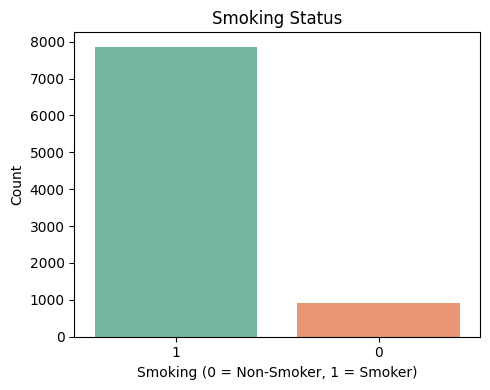

In [35]:
# My code here
plt.figure(figsize=(5, 4))
sns.countplot(data=lifestyle, x='Smoking', order=lifestyle['Smoking'].value_counts().index, palette='Set2')
plt.title('Smoking Status')
plt.xlabel('Smoking (0 = Non-Smoker, 1 = Smoker)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [40]:
n = len(lifestyle)
smokers = int(lifestyle['Smoking'].sum())
print(f"Smokers: {smokers} / {n} ({smokers/n:.1%})")

Smokers: 7859 / 8763 (89.7%)


/tmp/ipykernel_8304/2235796265.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=lifestyle, x='Diet', order=lifestyle['Diet'].value_counts().index, palette='Set1')


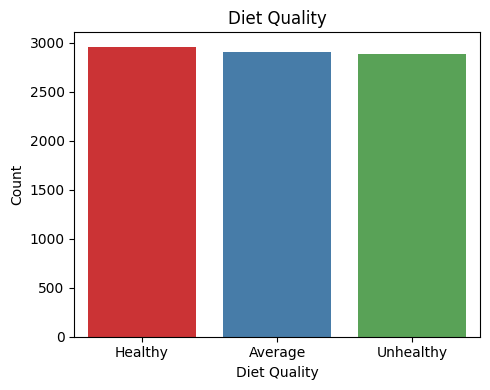

In [36]:
# My code here
plt.figure(figsize=(5, 4))
sns.countplot(data=lifestyle, x='Diet', order=lifestyle['Diet'].value_counts().index, palette='Set1')
plt.title('Diet Quality')
plt.xlabel('Diet Quality')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [41]:
diet_counts = lifestyle['Diet'].value_counts()
print("\nDiet counts:\n", diet_counts)
print("\nMost common diet:", diet_counts.idxmax(), f"({diet_counts.max()} patients)")


Diet counts:
 Diet
Healthy      2960
Average      2912
Unhealthy    2891
Name: count, dtype: int64

Most common diet: Healthy (2960 patients)


/tmp/ipykernel_8304/4032747011.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_countries.index, y=top10_countries.values, palette='Blues_d')


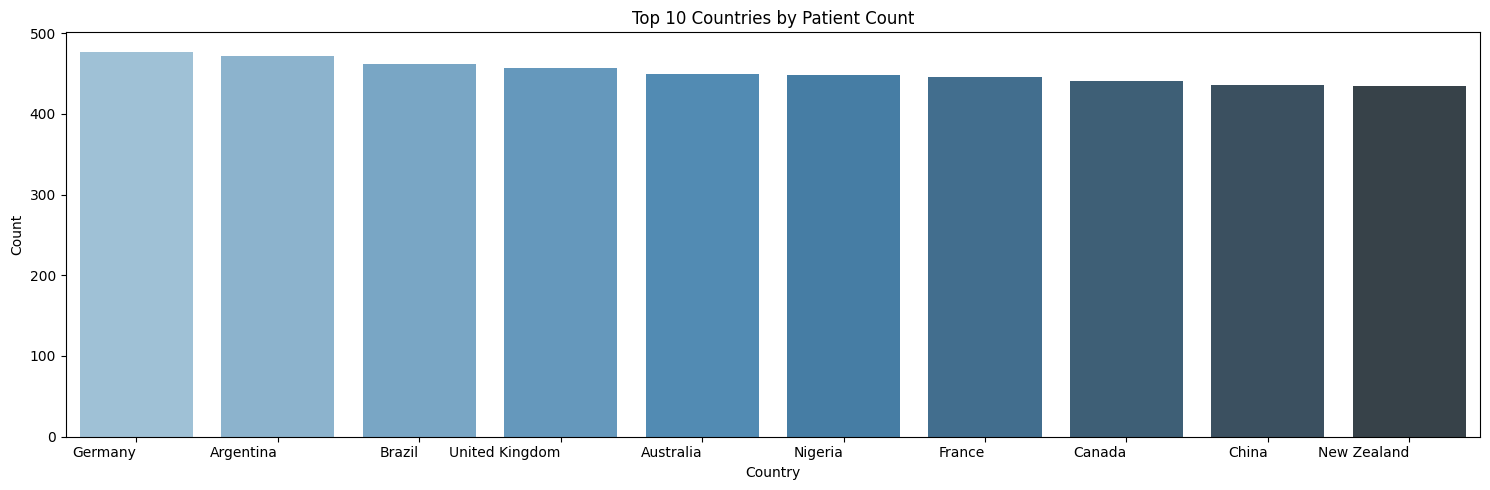

In [42]:
# My code here
top10_countries = demographics['Country'].value_counts().head(10)

plt.figure(figsize=(15, 5))
sns.barplot(x=top10_countries.index, y=top10_countries.values, palette='Blues_d')
plt.title('Top 10 Countries by Patient Count')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

In [45]:
print(top10_countries)

Country
Germany           477
Argentina         471
Brazil            462
United Kingdom    457
Australia         449
Nigeria           448
France            446
Canada            440
China             436
New Zealand       435
Name: count, dtype: int64


### Questions:
- What proportion of patients smoke?<br>
Answer: About 89.7% patients smoke.<br><br>
- Which diet category is most common?<br>
ANswer: <br>
Diet        Diet counts
Healthy      2960
Average      2912
Unhealthy    2891
Most common diet is Healthy with 2960 patients <br><br>
- Which countries are most represented?
Answer: Mostly represented countries are:<br>
    * Germany
    * Argentina
    * Brazil
    * UK
    * Australia
    * Nigeria
    * France
    * Canada
    * China
    * New Zealand


# Bivariate Analysis : Features vs Target

## Context
Bivariate analysis explores the relationship **between two variables**.
Here, we are specifically interested in how each feature relates to `Heart Attack Risk` (our target).

This is where we start forming hypotheses:
- Do smokers have higher risk?
- Does diet quality affect risk?
- Does cholesterol level differ between risk groups?

---

## Categorical Features vs Heart Attack Risk (Grouped Bar Charts)

### Task:
For the categorical features: Smoking, Diet, Sex, create a grouped bar chart showing the count of At-Risk vs Not-At-Risk patients within each category.

### Questions:
- Do smokers show noticeably higher risk counts?
- Does diet quality appear protective against heart attack risk?
- Is there a difference in risk between male and female patients?

### Hint:
- `sns.countplot(data=df, x='Smoking', hue='Heart Attack Risk')` creates grouped bars automatically
- `hue` splits each bar group by the target variable
- To see proportions (not raw counts) within groups, compute:
  `df.groupby('Smoking')['Heart Attack Risk'].mean()` → gives risk rate per group

### Why This Matters:
Raw counts can be misleading if groups have unequal sizes. Consider also plotting proportions (risk rate) to compare groups fairly.

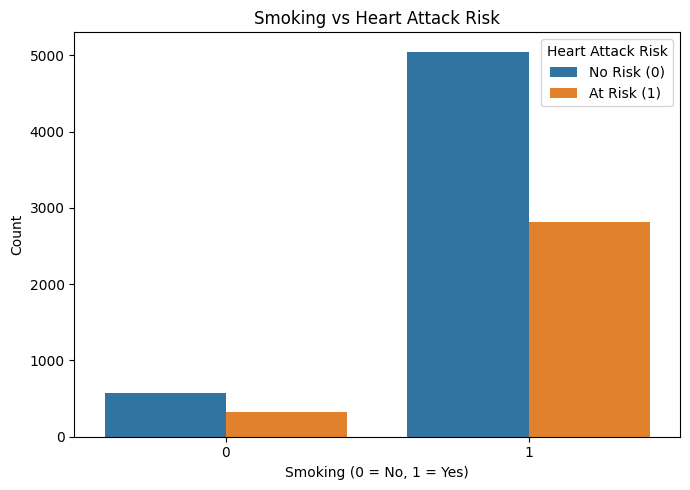

Risk rate by Smoking status:
Smoking
0    0.364
1    0.358
Name: Heart Attack Risk, dtype: float64


In [46]:
# My code here
# Smoking vs Heart Attack Risk
plt.figure(figsize=(7, 5))
sns.countplot(data=lifestyle, x='Smoking', hue='Heart Attack Risk')
plt.title('Smoking vs Heart Attack Risk')
plt.xlabel('Smoking (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.legend(title='Heart Attack Risk', labels=['No Risk (0)', 'At Risk (1)'])
plt.tight_layout()
plt.show()

print('Risk rate by Smoking status:')
print(lifestyle.groupby('Smoking')['Heart Attack Risk'].mean().round(3))

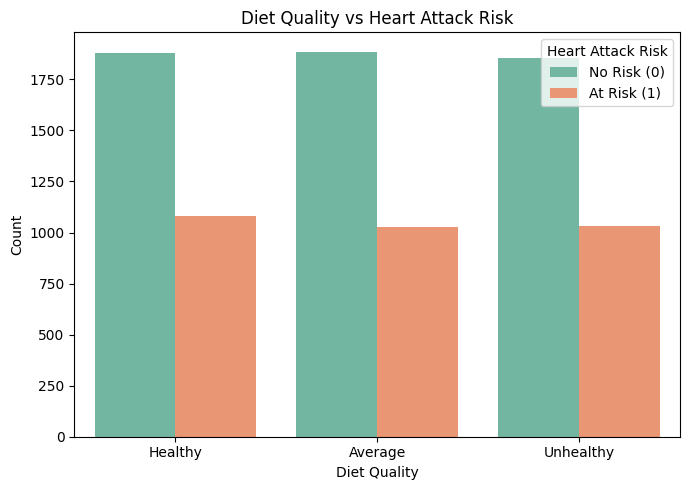

Risk rate by Diet quality:
Diet
Average      0.352
Healthy      0.365
Unhealthy    0.358
Name: Heart Attack Risk, dtype: float64


In [47]:
# My code here
# Diet vs Heart Attack Risk
plt.figure(figsize=(7, 5))
sns.countplot(data=lifestyle, x='Diet', hue='Heart Attack Risk',
              order=['Healthy', 'Average', 'Unhealthy'], palette='Set2')
plt.title('Diet Quality vs Heart Attack Risk')
plt.xlabel('Diet Quality')
plt.ylabel('Count')
plt.legend(title='Heart Attack Risk', labels=['No Risk (0)', 'At Risk (1)'])
plt.tight_layout()
plt.show()

print('Risk rate by Diet quality:')
print(lifestyle.groupby('Diet')['Heart Attack Risk'].mean().round(3))

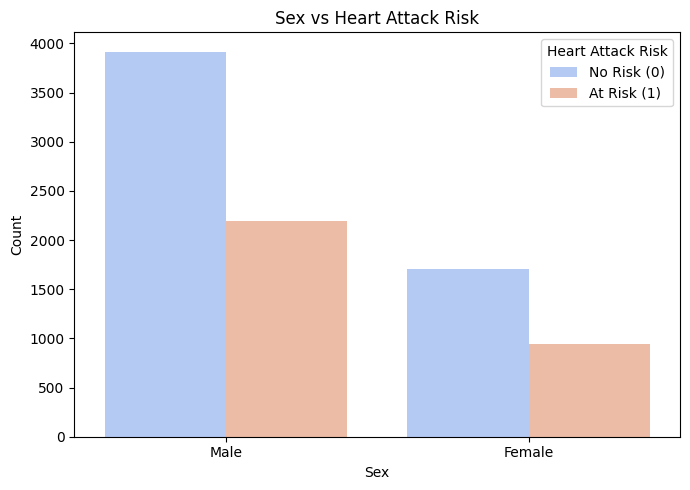

Risk rate by Sex:
Sex
Female    0.356
Male      0.359
Name: Heart Attack Risk, dtype: float64


In [65]:
# My code here
# Sex vs Heart Attack Risk
# Merged demographics and lifestyle on Patient ID first
merged = demographics[['Patient ID', 'Sex']].merge(
    lifestyle[['Patient ID', 'Heart Attack Risk']], on='Patient ID'
)

plt.figure(figsize=(7, 5))
sns.countplot(data=merged, x='Sex', hue='Heart Attack Risk', palette='coolwarm')
plt.title('Sex vs Heart Attack Risk')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.legend(title='Heart Attack Risk', labels=['No Risk (0)', 'At Risk (1)'])
plt.tight_layout()
plt.show()

print('Risk rate by Sex:')
print(merged.groupby('Sex')['Heart Attack Risk'].mean().round(3))

### Questions:
- Do smokers show noticeably higher risk counts?<br>
Answer: Yes because almost 90% of sample are smokers. So, number at risk will be higher.<br><br>
- Does diet quality appear protective against heart attack risk?<br>
Answer: <br>
From the chart, only small difference can be seen.  Since, there is no differences that are statistically significant, we cannot tell if diet quality appears to be protective against heart attack risk.
<br>

- Is there a difference in risk between male and female patients?<br>
Answer: <br>
Sex       Risk Rate
Female    0.356
Male      0.359
<br>
From given datas, there is no significant difference but Male are more prone to Heart Attack Risk than Female.

# Correlation Analysis

## Context
Correlation measures **how strongly two numerical variables move together**.

### Some types of Correlation Coefficient:
| Coefficient | Use Case | Range |
|---|---|---|
| **Pearson** | Linear relationship between continuous variables | -1 to +1 |
| **Spearman** | Monotonic (ranked) relationship; robust to outliers | -1 to +1 |

### Interpretation Guide:
- |r| > 0.7 → Strong correlation  
- |r| 0.4–0.7 → Moderate correlation  
- |r| < 0.4 → Weak correlation  
- Sign (+ or -) tells direction: positive = both increase together, negative = one increases as other decreases

---

## Pearson Correlation Heatmap

### Task:
Calculate and visualize the Pearson correlation matrix for all numerical columns including the target.

### Questions:
- Which feature has the highest correlation with Heart Attack Risk?
- Are any features highly correlated with each other (multicollinearity)?
- Does Systolic BP correlate strongly with Diastolic BP? Why might that be expected?

### Hint:
- `df[numeric_cols].corr(method='pearson')` computes the correlation matrix
- `sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')` visualizes it
- `mask = np.triu(np.ones_like(corr_matrix))` removes the duplicate upper triangle

### Warning:
Pearson assumes linearity and is sensitive to outliers. For skewed distributions, consider Spearman instead.

In [50]:
# Merging all numeric datasets for correlation analysis
merged_all = demographics[['Patient ID', 'Age']].merge(
    clinical.drop(columns=['Blood Pressure']), on='Patient ID'
).merge(
    lifestyle[['Patient ID', 'Heart Attack Risk', 'Stress Level', 'Exercise Hours Per Week']], on='Patient ID'
)
merged_all.head()

,Patient ID,Age,Cholesterol,Heart Rate,Diabetes,Family History,Triglycerides,BMI,Systolic,Diastolic,Heart Attack Risk,Stress Level,Exercise Hours Per Week
0,BMW7812,67,208,72,0,0,286,31.251233,158,88,0,9,4.168189
1,CZE1114,21,389,98,1,1,235,27.194973,165,93,0,1,1.813242
2,BNI9906,21,324,72,1,0,587,28.176571,174,99,0,9,2.078353
3,JLN3497,84,383,73,1,1,378,36.464704,163,100,0,9,9.828130
4,GFO8847,66,318,93,1,1,231,21.809144,91,88,0,6,5.804299


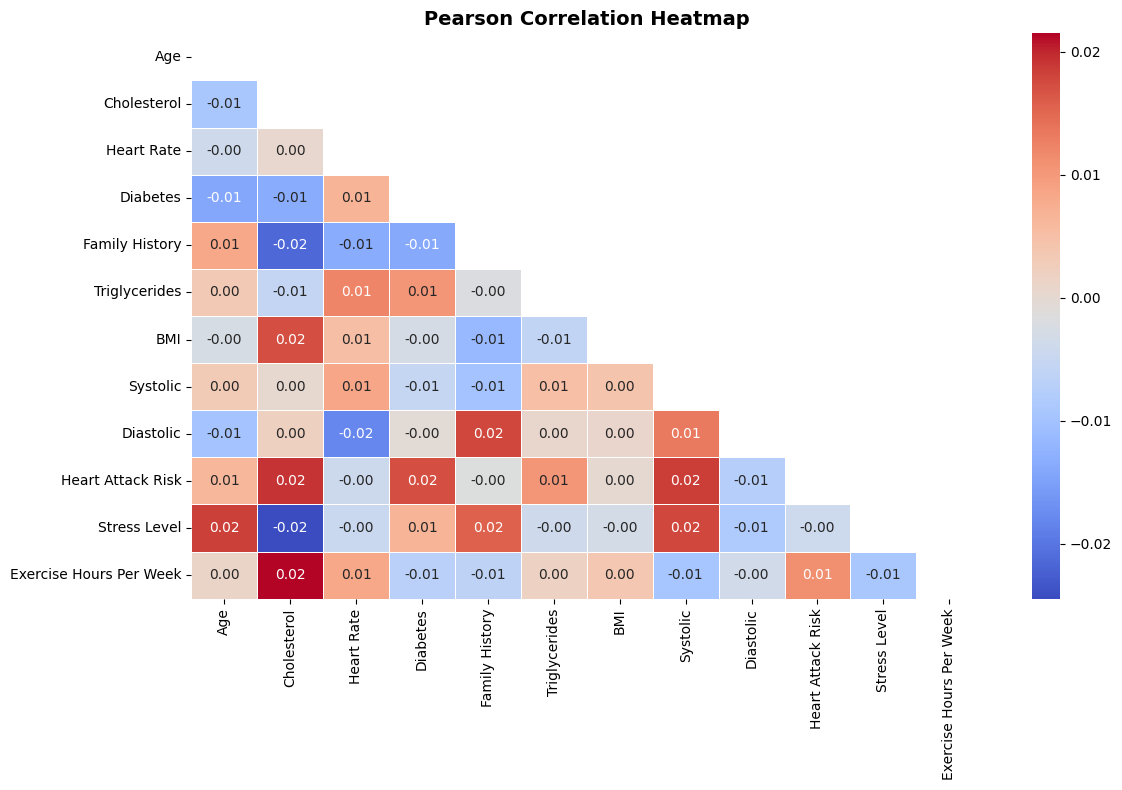

In [51]:
# Pearson Correlation Heatmap
numeric_cols = merged_all.select_dtypes(include=[np.number]).columns.tolist()
corr_pearson = merged_all[numeric_cols].corr(method='pearson')

# Mask upper triangle to avoid duplicate info
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

plt.figure(figsize=(12, 8))
sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', fmt='.2f',
            mask=mask, linewidths=0.5)
plt.title('Pearson Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [52]:
# feature that correlates most with Heart Attack Risk?
risk_corr = corr_pearson['Heart Attack Risk'].drop('Heart Attack Risk').sort_values(key=abs, ascending=False)
print('Pearson Correlation with Heart Attack Risk (sorted by absolute value):')
print(risk_corr.round(3))

Pearson Correlation with Heart Attack Risk (sorted by absolute value):
Cholesterol                0.019
Systolic                   0.019
Diabetes                   0.017
Exercise Hours Per Week    0.011
Triglycerides              0.010
Diastolic                 -0.008
Age                        0.006
Heart Rate                -0.004
Stress Level              -0.004
Family History            -0.002
BMI                        0.000
Name: Heart Attack Risk, dtype: float64


In [54]:
merged_all['Systolic'].corr(merged_all['Diastolic'])

np.float64(0.013337009298239395)

### Questions:
- Which feature has the highest correlation with Heart Attack Risk?<br>
Answer: Cholesterol, Systolic have the highest correlation with Heart Attack Risk. <br><br>
- Are any features highly correlated with each other (multicollinearity)?<br>
Answer: From the listed Pearson correlations with the target, none of the features show a strong relationship with Heart Attack Risk. That alone doesn't prove predictors are not collinear with each other.<br><br>
- Does Systolic BP correlate strongly with Diastolic BP? Why might that be expected?<br>
Answer: Systolic and Diastolic BP are usually correlated. According to Pearson correlation:<br>
measured correlation ≈ 0.013 (np.float64(0.013337...)) is essentially zero.

# Spearman Correlation

### Task:
Repeat the correlation analysis using Spearman's rank correlation.

### Questions:
- Are the Spearman results significantly different from Pearson?
- If they differ, what might that suggest about the data's linearity or outliers?

### Hint:
- Use `method='spearman'` in `.corr()`
- Compare the two heatmaps side by side using `plt.subplots(1, 2)`

### Interpretation:
Large differences between Pearson and Spearman suggest the relationship is non-linear or that outliers are influencing Pearson.

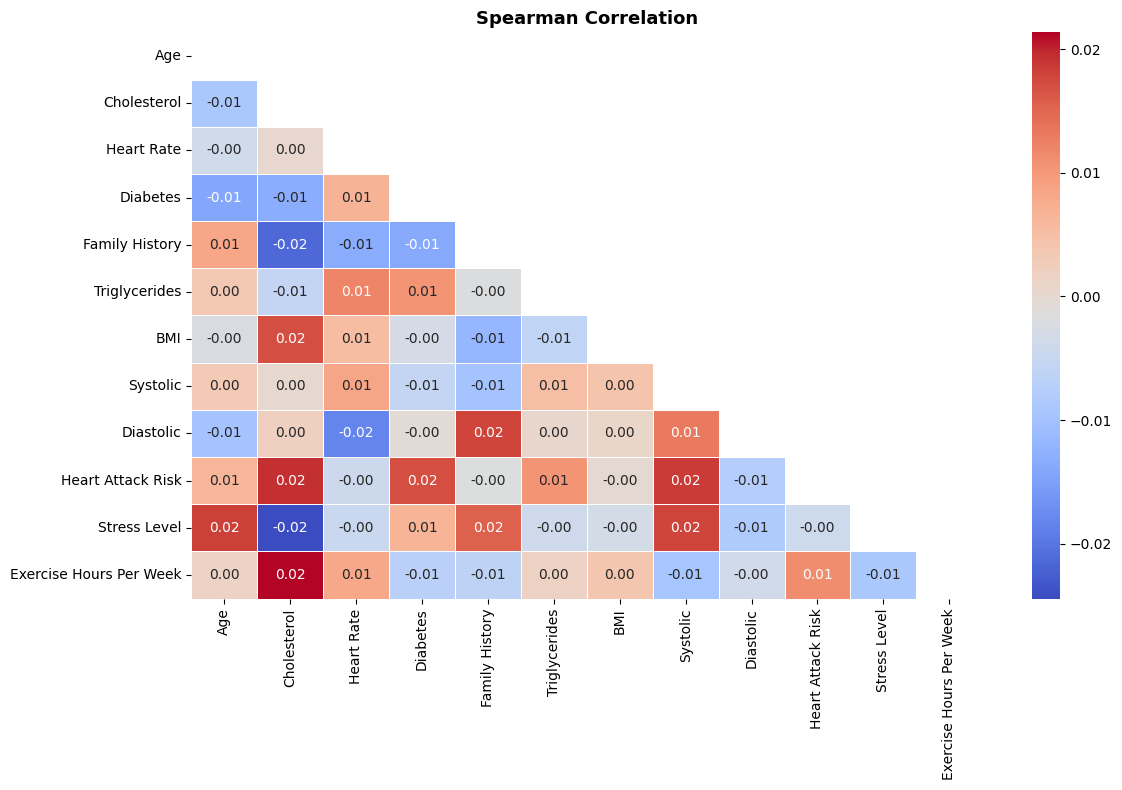

In [58]:
# My code here
# Compare Pearson vs Spearman side by side
corr_spearman = merged_all[numeric_cols].corr(method='spearman')

fig, axes = plt.subplots(figsize=(12, 8))

sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', fmt='.2f',
            mask=mask, linewidths=0.5)
plt.title('Spearman Correlation', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [59]:
# Comparing Pearson vs Spearman correlation with Heart Attack Risk
risk_spearman = corr_spearman['Heart Attack Risk'].drop('Heart Attack Risk').sort_values(key=abs, ascending=False)

comparison = pd.DataFrame({
    'Pearson': corr_pearson['Heart Attack Risk'].drop('Heart Attack Risk'),
    'Spearman': corr_spearman['Heart Attack Risk'].drop('Heart Attack Risk')
})
comparison['Difference'] = (comparison['Pearson'] - comparison['Spearman']).abs()
print('Pearson vs Spearman comparison (with Heart Attack Risk):')
print(comparison.sort_values('Difference', ascending=False).round(3))

Pearson vs Spearman comparison (with Heart Attack Risk):
                         Pearson  Spearman  Difference
Diastolic                 -0.008    -0.008         0.0
Heart Rate                -0.004    -0.004         0.0
BMI                        0.000    -0.000         0.0
Cholesterol                0.019     0.019         0.0
Systolic                   0.019     0.019         0.0
Exercise Hours Per Week    0.011     0.011         0.0
Age                        0.006     0.006         0.0
Triglycerides              0.010     0.010         0.0
Stress Level              -0.004    -0.004         0.0
Diabetes                   0.017     0.017         0.0
Family History            -0.002    -0.002         0.0


In [60]:
# Interpretation: Check if large differences exist
threshold = 0.05
large_diff = comparison[comparison['Difference'] > threshold]
if len(large_diff) > 0:
    print('Features with notable Pearson vs Spearman difference (>0.05):')
    print(large_diff.round(3))
    print('\n=> These features may have non-linear relationships or are affected by outliers.')
else:
    print('Pearson and Spearman results are very similar.')
    print('=> Relationships are likely linear and not strongly influenced by outliers.')

Pearson and Spearman results are very similar.
=> Relationships are likely linear and not strongly influenced by outliers.


### Questions:
- Are the Spearman results significantly different from Pearson?<br>
Answer: No, the Spearman results are very similar to the Pearson results (no notable differences), so the numeric relationships appear roughly linear and not dominated by rank-only effects or extreme outliers.<br><br>
- If they differ, what might that suggest about the data's linearity or outliers?<br>
ANswer: That would suggest either a non‑linear but monotonic relationship.

## Target Variable Analysis: Heart Attack Risk

## Context
Target variable is the variable that the user would want to predict using the rest of the dataset.

`Heart Attack Risk` is a **binary variable**: 0 (No Risk) and 1 (At Risk).

## Tasks:
- Count how many patients fall into each class
- Visualize the class distribution with a bar chart

## Hint:
- Use `.value_counts()` to get counts
- Use `sns.countplot()` or `plt.bar()` for visualization


In [63]:
# Calculating
risk_counts = lifestyle['Heart Attack Risk'].value_counts()
print('Heart Attack Risk class distribution:')
print(risk_counts)
print("-------------------------------")
print(f'\nClass balance: {risk_counts[0]} No Risk vs {risk_counts[1]} At Risk')
print(f'At Risk proportion: {risk_counts[1]/risk_counts.sum():.1%}')

Heart Attack Risk class distribution:
Heart Attack Risk
0    5624
1    3139
Name: count, dtype: int64
-------------------------------

Class balance: 5624 No Risk vs 3139 At Risk
At Risk proportion: 35.8%


/tmp/ipykernel_8304/2610136181.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=lifestyle, x='Heart Attack Risk',


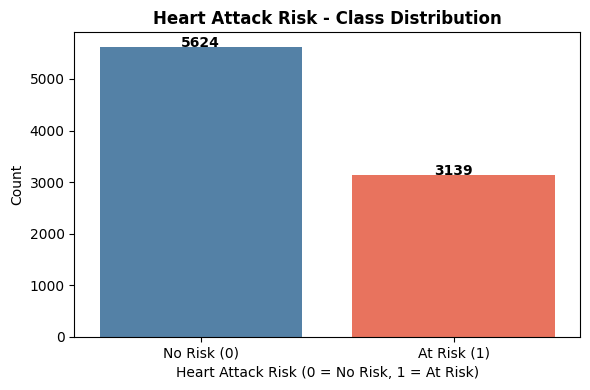

In [64]:
# Bar chart of Heart Attack Risk
plt.figure(figsize=(6, 4))
sns.countplot(data=lifestyle, x='Heart Attack Risk',
              palette=['steelblue', 'tomato'])
plt.title('Heart Attack Risk - Class Distribution', fontweight='bold')
plt.xlabel('Heart Attack Risk (0 = No Risk, 1 = At Risk)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Risk (0)', 'At Risk (1)'])
for i, count in enumerate(risk_counts.sort_index()):
    plt.text(i, count + 5, str(count), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Final Reflection

## Answer the following:

### 1. Missing Values
- How did you handle missing values in each dataset?
- Why did you choose that approach (drop, fill, or mixed strategy)?

---

### 2. Data Quality Issues
- Did you find any unrealistic or inconsistent values?
- How did you identify them?
- What action did you take (remove, clip, correct, or keep)?

---

### 3. Insights from EDA
- What patterns did you observe in the data?
- Did you find any relationships between variables (e.g., age, cholesterol, risk)?
- Were there any surprising findings or trends?

---

### 4. Correlation Findings
- Were Pearson and Spearman results similar or different? What does that suggest?
- Did you find any multicollinearity (two features highly correlated with each other)?

---

### 5. Improvements
- If you had more time, what would you improve in your data cleaning process?
- Would you try different strategies for missing values or outliers?
- What additional checks or visualizations would you add?

---

### Tip
There is no single correct answer here. Focus on:
- Justifying your decisions  
- Explaining trade-offs  
- Demonstrating understanding of data quality impact  

### Answer here:

### 1. Missing Values
- How did you handle missing values in each dataset?<br>
Answer: 
    * Firstly, I inspected with .head(),.describe() and since <br> clinical.isna().sum(), demographics.isna().sum(), lifestyle.isna().sum() returned all zeros which implies there are no empty fields or null values encoded in the CSVs.<br>
    * Raw files showed no empty fields or common tokens (NA, None, N/A) i.e. missingness is not encoded as true nulls.<br><br>

- Why did you choose that approach (drop, fill, or mixed strategy)?<br>
Answer: Since, .isna().sum() returning zeros is consistent with the files and there are no explicit missing values encoded in those CSVs, approaches like drop,fill or mixed stratefy was skipped.

---

### 2. Data Quality Issues
- Did you find any unrealistic or inconsistent values?<br>
Answer: Few data issues that can be seen are:<br>
    * Values that are supposed to be of dtype numeric is string. For eg: Blood Pressure is stored like "120/80"
    * There could be outliers,duplicates and inconsistent entries as well.
    * 'Blood Pressure' column should be split into Systolic and Diastolic in integer but is stored as object/string.<br><br>
- How did you identify them?<br>
Answer: .head(), .info(), .describe(), histograms/KDEs, manual inspection of CSVs and unique values were printed to check.<br><br>

- What action did you take (remove, clip, correct, or keep)?<br>
Answer: Split Blood Pressure into Systolic/Diastolic with the help of regular expression, for duplicates, checked and resolved Patient ID before merges.

---

### 3. Insights from EDA
- What patterns did you observe in the data?<br>
Answer: Very high smoking prevalence (~89.7%); diet categories roughly balanced; class balance for Heart Attack Risk appears roughly even;Among Age, Cholesterol and BMI, none are perfectly normally distributed. They are approximately symmetrical as their values lies between [-0.5,0.5].<br><br>
- Did you find any relationships between variables (e.g., age, cholesterol, risk)?<br>
Answer: Cholesterol, Systolic have the highest correlation with Heart Attack Risk. <br>From the listed correlations with the target, none of the features show a strong relationship with Heart Attack Risk. <br>Systolic and Diastolic BP are usually correlated. According to correlation measured:<br>
measured correlation ≈ 0.013 (np.float64(0.013337...)) is essentially zero.<br>Age/BMI approximately symmetric by crude skew checks but with spikes.<br><br>
- Were there any surprising findings or trends?<br>
Answer:  Surprisingly, Systolic vs Diastolic correlation ≈ 0.013 (near zero), physiologically unexpected.

---

### 4. Correlation Findings
- Were Pearson and Spearman results similar or different? What does that suggest?<br>
Answer: No, the Spearman results are very similar to the Pearson results (both showed only tiny little correlation ~0.019), so the numeric relationships appear roughly linear and not dominated by rank-only effects or extreme outliers.<br>
It implies that the relationships are weak and not mainly monotonic-only or driven by rank effects/outliers.<br><br>

- Did you find any multicollinearity (two features highly correlated with each other)? <br>
Answer: From the listed correlations with the target, none of the features show a strong relationship with Heart Attack Risk. That alone doesn't prove predictors are not collinear with each other. And, Systolic and Diastolic BP are usually correlated. According to correlation measured:<br>
measured correlation ≈ 0.013 (np.float64(0.013337...)) is approx 0. <br><br>

---

### 5. Improvements
- If you had more time, what would you improve in your data cleaning process?<br>
Answer: If I had more time:<br>
    * Replace texts/strings with integers (with np.nan) and re-parse BP robustly, and re-run the correlation checks by evaluating from p-value.
- Would you try different strategies for missing values or outliers?<br>
Answer: I would use use IQR/domain thresholds + manual review for outliers (clip/winsorize only after checking provenance)<br><br>
- What additional checks or visualizations would you add?<br>
Answer: Extra visual checks likescatter Systolic vs Diastolic, boxplots by risk group, log1p transformations for skewed labs,and pairwise scatterplot.
Immediate fixes: replace text-like missing tokens with np.nan, re-parse Blood Pressure robustly, and re-run paired-count and correlation checks.
Outlier/missing strategy: apply feature-wise rules — median/multivariate imputation for clinical labs, Unknown for survey items, and missingness indicators for important features, run logistic regression (age/sex/smoking + candidate labs), compare univariate vs adjusted effects, and test statistical significance (chi-square / Fisher for categorical).
